In [1]:
from ema_workbench import load_results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

def load_combined_dataframe(filename):
    """Load experiments and outcomes and merge into one DataFrame."""
    experiments, outcomes = load_results(filename)
    experiments_df = pd.DataFrame(experiments)
    outcomes_df = pd.DataFrame(outcomes)
    combined_df = pd.concat(
        [experiments_df.reset_index(drop=True), outcomes_df.reset_index(drop=True)],
        axis=1
    )
    return experiments_df, outcomes_df, combined_df

filename = 'ema_resultsprobstate3.tar.gz'
experiments_df, outcomes_df, combined_df = load_combined_dataframe(filename)


In [2]:
def preview_data(experiments_df, outcomes_df):
    print("Available outcomes:")
    print(outcomes_df.columns.tolist())
    print("\nSample of experiments:")
    print(experiments_df.head())

preview_data(experiments_df, outcomes_df)


Available outcomes:
['A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs']

Sample of experiments:
   A.0_ID flood wave shape    A.1_Bmax A.1_Brate  A.1_pfail    A.2_Bmax  \
0                       59  145.696909       1.5   0.620286   58.229759   
1                       63  272.736871      10.0   0.244607  341.792038   
2                      130  194.985110       1.5   0.567211  119.977100   
3                       41  213.038998      10.0   0.023910  229.967950   
4                       49  139.235409      10.0   0.866088  103.950106   

  A.2_Brate  A.2_pfail    A.3_Bmax A.3_Brate  A.3_pfail  ...  \
0      10.0   0.868944  118.279228      10.0   0.140612  ...   
1      10.0   0.624974  269.491989      10.0   0.921079  ...   
2   

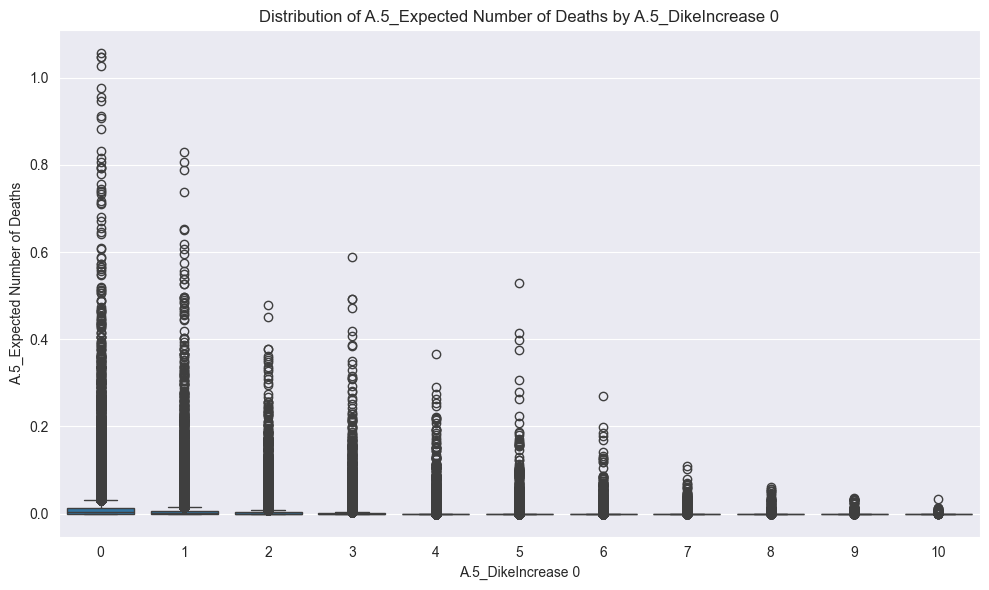

In [4]:
def plot_deaths_by_lever(df, lever_column, outcome_column):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=lever_column, y=outcome_column, data=df)
    plt.title(f"Distribution of {outcome_column} by {lever_column}")
    plt.tight_layout()
    plt.show()

plot_deaths_by_lever(combined_df, 'A.5_DikeIncrease 0', 'A.5_Expected Number of Deaths')


In [5]:
def get_best_policies(df, outcome_col, lever_subset, n=10):
    best = df.nsmallest(n, outcome_col)
    print(best[lever_subset + [outcome_col]])
    return best

policy_vars_grouped = ['A.5_DikeIncrease 0', '4_RfR 0', 'EWS_DaysToThreat']
deaths_col = 'A.5_Expected Number of Deaths'
best_policies = get_best_policies(combined_df, deaths_col, policy_vars_grouped)


   A.5_DikeIncrease 0  4_RfR 0  EWS_DaysToThreat  \
0                  10        1                 4   
1                  10        1                 4   
2                  10        1                 4   
3                  10        1                 4   
4                  10        1                 4   
5                  10        1                 4   
6                  10        1                 4   
7                  10        1                 4   
8                  10        1                 4   
9                  10        1                 4   

   A.5_Expected Number of Deaths  
0                            0.0  
1                            0.0  
2                            0.0  
3                            0.0  
4                            0.0  
5                            0.0  
6                            0.0  
7                            0.0  
8                            0.0  
9                            0.0  


In [6]:
def summarize_by_policy(df, outcome_col, policy_col='policy'):
    levers = [col for col in df.columns if 'DikeIncrease' in col or 'RfR' in col or 'EWS' in col]
    summary = df.groupby(policy_col).agg(
        mean_outcome=(outcome_col, 'mean'),
        **{lever: (lever, 'first') for lever in levers}
    ).reset_index()
    summary['policy_id'] = summary[levers].astype(str).agg('-'.join, axis=1)
    return summary, levers

policy_summary, policy_levers = summarize_by_policy(combined_df, deaths_col)


/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_94426/1404701727.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(policy_col).agg(


In [16]:
def summarize_by_policy(df, outcome_col, lever_list, policy_col='policy'):
    """
    Group by policy and compute mean outcome + lever settings.

    Parameters:
        df: DataFrame containing results
        outcome_col: the outcome to summarize (e.g., deaths)
        lever_list: explicit list of lever columns (not auto-detected)
        policy_col: policy ID column (default='policy')

    Returns:
        summary_df, lever_list (for downstream use)
    """
    summary = df.groupby(policy_col).agg(
        mean_outcome=(outcome_col, 'mean'),
        **{lever: (lever, 'first') for lever in lever_list}
    ).reset_index()

    summary['policy_id'] = summary[lever_list].astype(str).agg('-'.join, axis=1)
    return summary, lever_list


In [17]:
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]

policy_summary, policy_levers = summarize_by_policy(combined_df, deaths_col, policy_levers)


/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_94426/4137653765.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [9]:
def plot_policy_performance(df, y_col, levers, title, policy_col='policy_id'):
    fig = px.bar(
        df,
        x=policy_col,
        y=y_col,
        hover_data=levers + ['policy'],
        color=y_col,
        color_continuous_scale='Viridis',
        title=title,
        labels={policy_col: "Policy Combination", y_col: y_col}
    )
    fig.update_layout(
        xaxis_tickangle=45,
        xaxis_title="Policy Combination (DikeIncrease - RfR - EWS)",
        yaxis_title=y_col,
        width=900,
        height=600
    )
    fig.show()

# Top 50 lowest-death policies
top_policies = policy_summary.nsmallest(50, 'mean_outcome')
plot_policy_performance(top_policies, 'mean_outcome', policy_levers, "Top 50 Policies with Lowest Mean Deaths")

# Top 50 highest-death policies
worst_policies = policy_summary.nlargest(50, 'mean_outcome')
plot_policy_performance(worst_policies, 'mean_outcome', policy_levers, "Top 50 Policies with Highest Mean Deaths")


,policy,mean_outcome,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,EWS_DaysToThreat,RfR Total Costs,policy_id
1,1,0.000000e+00,0,0,0,0,0,0,0,0,...,8,0,3,0,10,4,6,3,2.868000e+08,0-0-0-0-0-0-0-0-1-0-0-0-0-1-0-0-3-9-0-10-10-10...
17,17,0.000000e+00,1,1,0,1,0,0,1,1,...,5,0,5,5,10,6,7,3,1.081800e+09,1-1-0-1-0-0-1-1-0-0-1-0-1-1-0-5-6-9-0-0-7-3-7-...
70,70,0.000000e+00,0,1,0,0,0,0,0,0,...,6,3,9,4,10,6,8,2,6.138000e+08,0-1-0-0-0-0-0-0-1-1-1-0-1-0-0-9-6-4-6-2-9-7-1-...
80,80,0.000000e+00,1,0,0,0,0,1,0,0,...,8,2,7,8,9,10,10,4,1.208900e+09,1-0-0-0-0-1-0-0-1-1-1-1-0-1-1-9-2-7-4-10-2-10-...
97,97,0.000000e+00,1,0,0,0,0,1,1,0,...,9,1,8,10,9,3,10,3,1.239600e+09,1-0-0-0-0-1-1-0-1-1-1-1-0-1-1-1-6-1-1-6-2-6-5-...
110,110,0.000000e+00,0,0,1,1,1,1,0,1,...,9,6,6,2,10,1,2,2,1.388400e+09,0-0-1-1-1-1-0-1-0-1-1-1-0-0-1-5-1-1-1-4-2-1-10...
114,114,0.000000e+00,1,0,1,1,0,0,1,0,...,10,1,5,2,10,8,4,4,5.389000e+08,1-0-1-1-0-0-1-0-0-0-0-1-0-0-0-6-0-10-9-1-5-4-6...
162,162,0.000000e+00,1,1,0,1,0,1,0,0,...,0,4,1,5,10,7,10,4,1.255200e+09,1-1-0-1-0-1-0-0-1-1-1-1-0-1-0-0-3-10-10-5-0-0-...
194,194,0.000000e+00,1,0,0,0,0,1,1,1,...,6,0,7,0,10,4,4,4,1.239600e+09,1-0-0-0-0-1-1-1-0-1-1-1-1-0-1-7-5-8-9-4-0-9-6-...
248,248,0.000000e+00,0,1,0,1,1,1,1,0,...,7,7,8,2,10,0,10,3,1.419100e+09,0-1-0-1-1-1-1-0-1-1-1-1-0-1-0-10-0-7-8-4-3-6-7...



--- Summary for Best Policies ---
                    count  mean       std  min   25%   50%    75%   max
0_RfR 0              50.0  0.48  0.504672  0.0  0.00   0.0   1.00   1.0
0_RfR 1              50.0  0.34  0.478518  0.0  0.00   0.0   1.00   1.0
0_RfR 2              50.0  0.42  0.498569  0.0  0.00   0.0   1.00   1.0
1_RfR 0              50.0  0.38  0.490314  0.0  0.00   0.0   1.00   1.0
1_RfR 1              50.0  0.36  0.484873  0.0  0.00   0.0   1.00   1.0
1_RfR 2              50.0  0.54  0.503457  0.0  0.00   1.0   1.00   1.0
2_RfR 0              50.0  0.40  0.494872  0.0  0.00   0.0   1.00   1.0
2_RfR 1              50.0  0.50  0.505076  0.0  0.00   0.5   1.00   1.0
2_RfR 2              50.0  0.42  0.498569  0.0  0.00   0.0   1.00   1.0
3_RfR 0              50.0  0.84  0.370328  0.0  1.00   1.0   1.00   1.0
3_RfR 1              50.0  0.80  0.404061  0.0  1.00   1.0   1.00   1.0
3_RfR 2              50.0  0.80  0.404061  0.0  1.00   1.0   1.00   1.0
4_RfR 0              50.0  0.

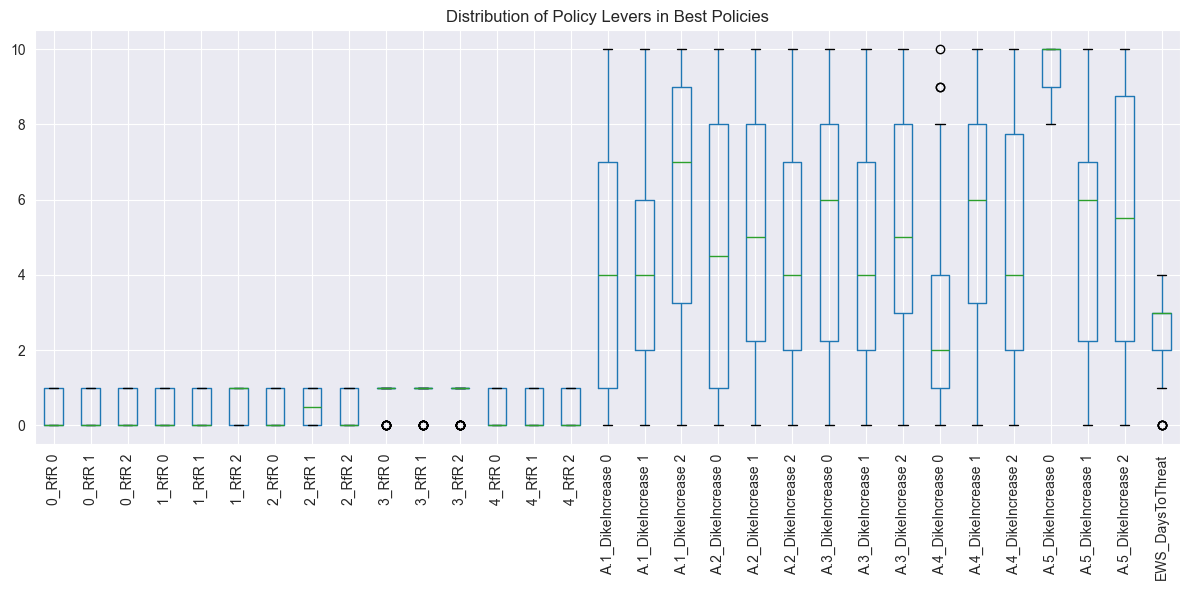


--- Summary for Worst Policies ---
                    count  mean       std  min   25%  50%   75%   max
0_RfR 0              50.0  0.62  0.490314  0.0  0.00  1.0  1.00   1.0
0_RfR 1              50.0  0.54  0.503457  0.0  0.00  1.0  1.00   1.0
0_RfR 2              50.0  0.58  0.498569  0.0  0.00  1.0  1.00   1.0
1_RfR 0              50.0  0.50  0.505076  0.0  0.00  0.5  1.00   1.0
1_RfR 1              50.0  0.62  0.490314  0.0  0.00  1.0  1.00   1.0
1_RfR 2              50.0  0.48  0.504672  0.0  0.00  0.0  1.00   1.0
2_RfR 0              50.0  0.48  0.504672  0.0  0.00  0.0  1.00   1.0
2_RfR 1              50.0  0.38  0.490314  0.0  0.00  0.0  1.00   1.0
2_RfR 2              50.0  0.48  0.504672  0.0  0.00  0.0  1.00   1.0
3_RfR 0              50.0  0.36  0.484873  0.0  0.00  0.0  1.00   1.0
3_RfR 1              50.0  0.18  0.388088  0.0  0.00  0.0  0.00   1.0
3_RfR 2              50.0  0.24  0.431419  0.0  0.00  0.0  0.00   1.0
4_RfR 0              50.0  0.56  0.501427  0.0  0.00  

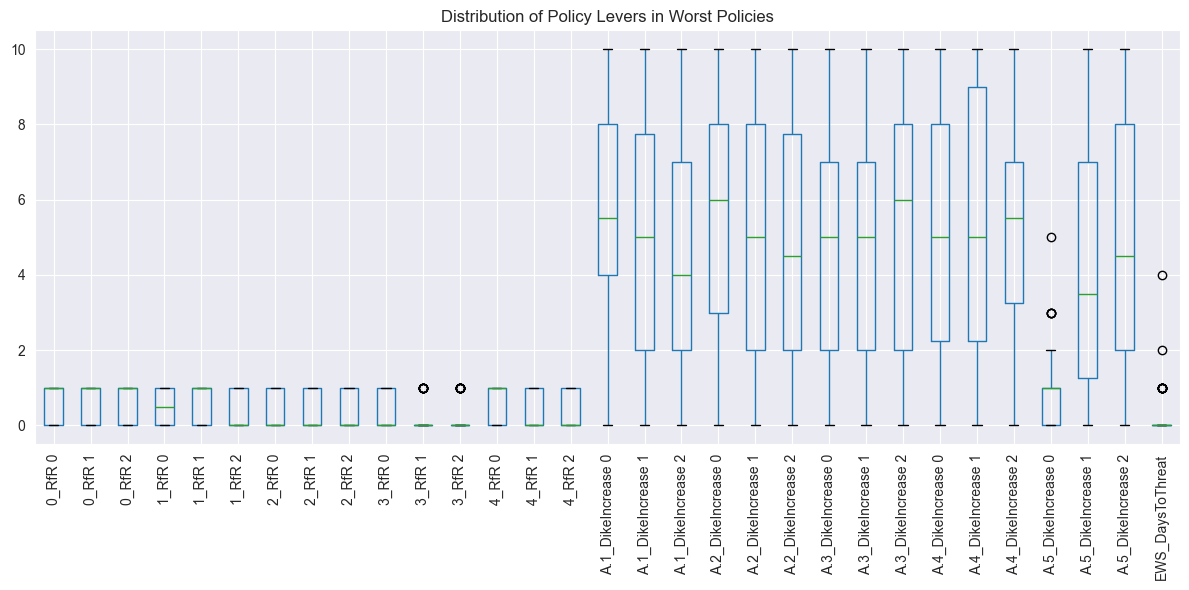

In [19]:
def analyze_levers(df, levers, label):
    print(f"\n--- Summary for {label} ---")
    print(df[levers].describe().T)

    modes = df[levers].mode()
    print("\nFirst mode (most common values):")
    print(modes.iloc[0].to_frame(name='Most_Common_Value'))

    print("\nAll modes (including ties):")
    print(modes)

    consistent = df[levers].nunique()
    print("\nLevers with the same value across all policies:")
    print(consistent[consistent == 1])

    plt.figure(figsize=(12, 6))
    df[levers].boxplot(rot=90)
    plt.title(f"Distribution of Policy Levers in {label}")
    plt.tight_layout()
    plt.show()

analyze_levers(top_policies, policy_levers, "Best Policies")
analyze_levers(worst_policies, policy_levers, "Worst Policies")
